# Initial-condition effects

For fixed $L$, $d$, and $c$, the panels sample $p^*(f_T)$ at four normalized positions in the valid $f_T$ interval over the $(p_0, P_0)$ plane. Missing simulations are left blank.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

notebook_dir = Path.cwd()
if not (notebook_dir / 'src').is_dir():
    notebook_dir = notebook_dir / 'jupyter'
sys.path.insert(0, str(notebook_dir / 'src'))

from src.initial_conditions import (
    get_initial_condition_combinations,
    get_missing_initial_condition_combinations,
    prepare_initial_condition_maps,
)

plt.style.use(notebook_dir / 'properties.mplstyle')

## Data preparation

In [2]:
L = 1024
dim = 2
c = 0.1
nc = 1
rho = 1.0
order = 0
rule_update = 'relative'

all_combinations = [
    (round(i, 1), round(j, 1))
    for i in np.arange(0.1, 1.1, 0.1)
    for j in np.arange(0.1, 1.1, 0.1)
]
df = pd.read_csv(notebook_dir.parent / 'SOP_data' / 'all_data_dynamic.dat', sep=r'\s+')

executed_combinations = get_initial_condition_combinations(
    df, L, dim=dim, c=c, nc=nc, rho=rho, order=order, rule_update=rule_update
)
missing_combinations = get_missing_initial_condition_combinations(
    df,
    L,
    all_combinations,
    dim=dim,
    c=c,
    nc=nc,
    rho=rho,
    order=order,
    rule_update=rule_update
)

print(f'{len(executed_combinations)} combinations already executed')
print(f'{len(missing_combinations)} combinations still missing')
missing_combinations

100 combinations already executed
0 combinations still missing


[]

In [4]:
prepared = prepare_initial_condition_maps(
    df,
    L,
    dim=dim,
    c=c,
    nc=nc,
    rho=rho,
    order=order,
    min_percolating_samples=5,
    min_percolating_fraction=1.00,
    rule_update=rule_update,
    p_star_min=0.0,
    p_star_max=0.9,
    f_T_max=0.4,
)

display(prepared['node']['summary'].head())
display(prepared['bond']['summary'].head())

,type_perc,p0,P0,f_T_min,f_T_one_third,f_T_two_thirds,f_T_max,delta_f_T,p_star_at_f_T_min,p_star_at_one_third,p_star_at_two_thirds,p_star_at_f_T_max,p_star_min,f_T_at_p_star_min,p_star_min_err,n_f_T
0,node,0.2,0.3,0.193158,0.223684,0.254211,0.284737,0.091579,0.599486,0.601557,0.604480,0.608181,0.599486,0.193158,0.000045,6
1,node,0.2,0.4,0.162632,0.203333,0.244035,0.284737,0.122105,0.598006,0.600166,0.603500,0.608478,0.598006,0.162632,0.000049,8
2,node,0.2,0.5,0.193158,0.223684,0.254211,0.284737,0.091579,0.599584,0.601738,0.604768,0.608683,0.599584,0.193158,0.000045,7
3,node,0.2,0.6,0.162632,0.203333,0.244035,0.284737,0.122105,0.598003,0.600194,0.603757,0.608863,0.598003,0.162632,0.000050,8
4,node,0.2,0.7,0.193158,0.223684,0.254211,0.284737,0.091579,0.599622,0.601792,0.604836,0.608988,0.599622,0.193158,0.000045,7


,type_perc,p0,P0,f_T_min,f_T_one_third,f_T_two_thirds,f_T_max,delta_f_T,p_star_at_f_T_min,p_star_at_one_third,p_star_at_two_thirds,p_star_at_f_T_max,p_star_min,f_T_at_p_star_min,p_star_min_err,n_f_T
0,bond,0.1,0.4,0.223684,0.233860,0.244035,0.254211,0.030526,0.504782,0.505109,0.505435,0.505762,0.504782,0.223684,0.000039,2
1,bond,0.1,0.5,0.254211,0.259298,0.264386,0.269474,0.015263,0.505742,0.505952,0.506161,0.506370,0.505742,0.254211,0.000035,2
2,bond,0.1,0.6,0.223684,0.244035,0.264386,0.284737,0.061053,0.504771,0.505408,0.506149,0.506988,0.504771,0.223684,0.000038,4
3,bond,0.1,0.7,0.254211,0.264386,0.274561,0.284737,0.030526,0.505730,0.506168,0.506606,0.507044,0.505730,0.254211,0.000033,2
4,bond,0.1,0.8,0.223684,0.244035,0.264386,0.284737,0.061053,0.504713,0.505380,0.506118,0.507051,0.504713,0.223684,0.000037,4


## Heatmaps

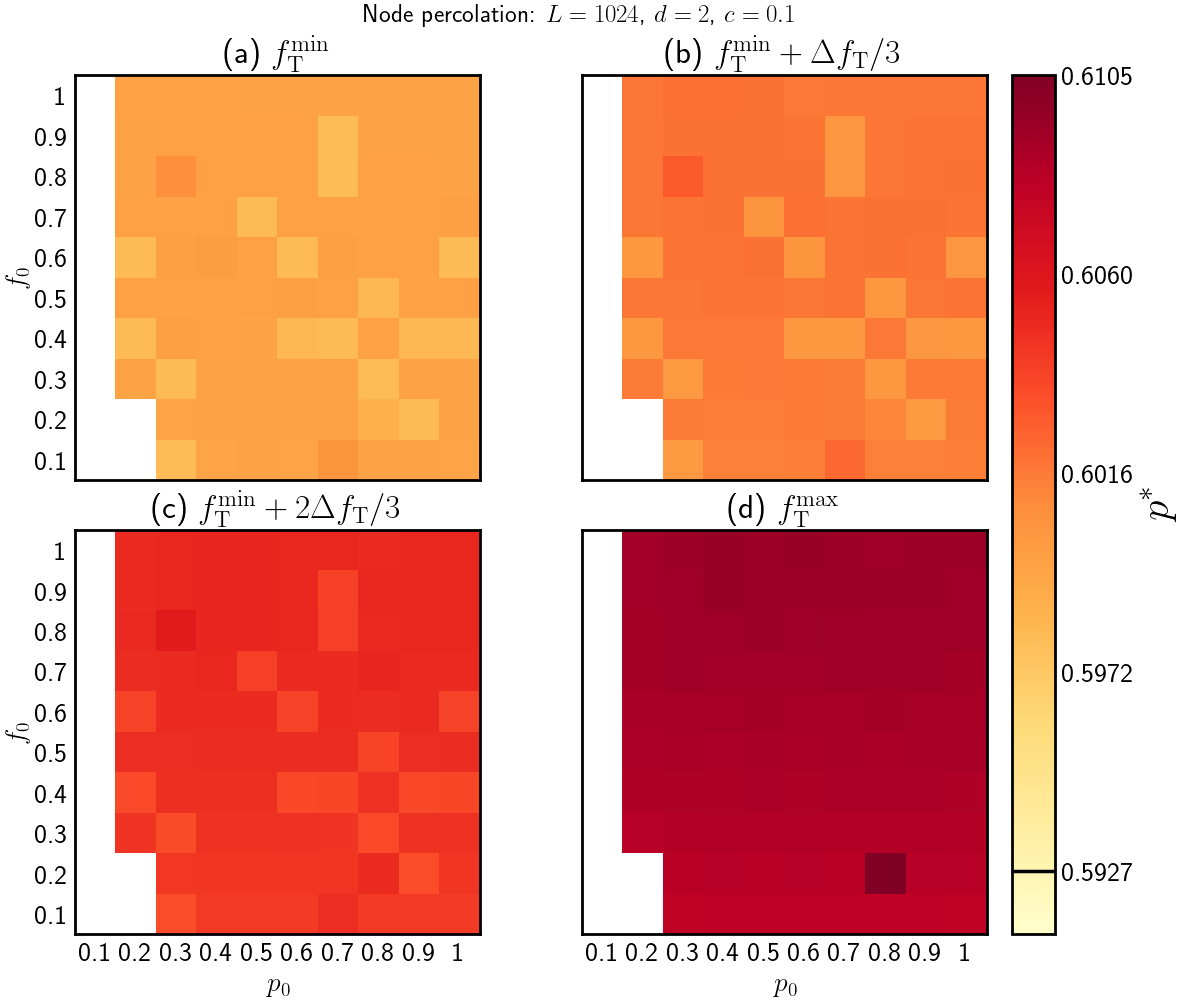

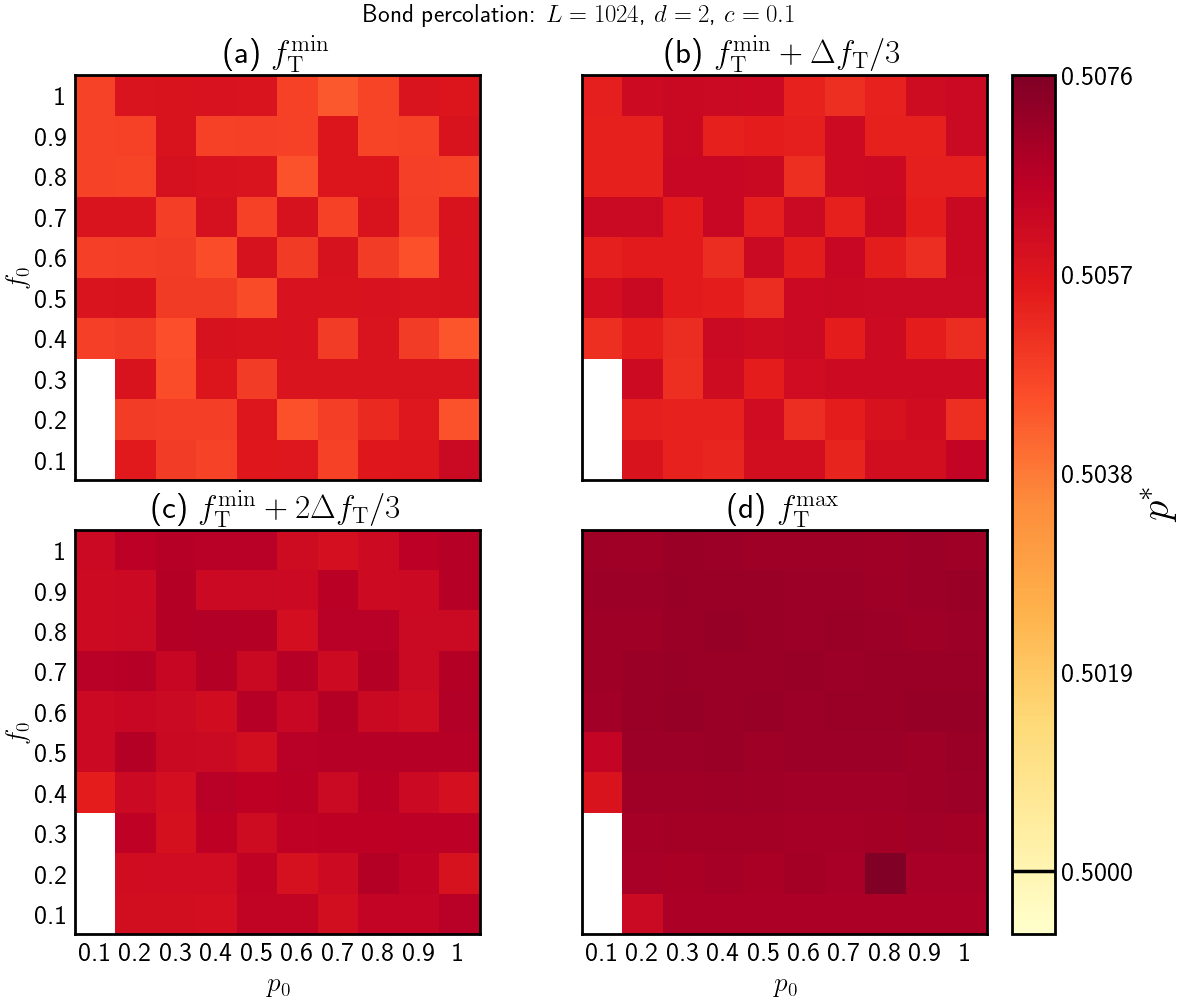

In [5]:
metrics = [
    ('p_star_at_f_T_min',       r'(a) $f_{\mathrm{T}}^{\mathrm{min}}$'),
    ('p_star_at_one_third',     r'(b) $f_{\mathrm{T}}^{\mathrm{min}} + \Delta f_{\mathrm{T}}/3$'),
    ('p_star_at_two_thirds',    r'(c) $f_{\mathrm{T}}^{\mathrm{min}} + 2\Delta f_{\mathrm{T}}/3$'),
    ('p_star_at_f_T_max',       r'(d) $f_{\mathrm{T}}^{\mathrm{max}}$'),
]

p_c_traditional = {
    'node': 0.59274605079210,
    'bond': 0.5,
}

for type_perc in ('node', 'bond'):
    fig, axes = plt.subplots(
        2, 2, figsize=(12, 10), sharex=True, sharey=True, constrained_layout=True
    )
    all_values = np.concatenate([
        prepared[type_perc]['maps'][metric].to_numpy(dtype=float).ravel()
        for metric, _ in metrics
    ])
    p_c = p_c_traditional[type_perc]
    vmax = np.nanmax(all_values)
    color_span = vmax - p_c
    vmin = p_c - 0.08 * color_span

    for index, (ax, (metric, title)) in enumerate(zip(axes.flat, metrics)):
        row, column = divmod(index, 2)
        matrix = prepared[type_perc]['maps'][metric]
        masked_values = np.ma.masked_invalid(matrix.to_numpy(dtype=float))
        image = ax.imshow(
            masked_values,
            origin='lower',
            aspect='equal',
            cmap='YlOrRd',
            vmin=vmin,
            vmax=vmax,
            interpolation='nearest',
        )

        ax.set_xticks(np.arange(len(matrix.columns)), labels=[f'{x:g}' for x in matrix.columns])
        ax.set_yticks(np.arange(len(matrix.index)), labels=[f'{y:g}' for y in matrix.index])
        ax.tick_params(
            axis='both',
            which='both',
            length=0,
            labelbottom=(row == 1),
            labelleft=(column == 0),
        )
        if row == 1:
            ax.set_xlabel(r'$p_0$')
        if column == 0:
            ax.set_ylabel(r'$f_0$')
        ax.set_title(title, pad=9)

    colorbar_ticks = np.linspace(p_c, vmax, 5)
    colorbar = fig.colorbar(
        image, ax=axes, location='right', fraction=0.045, pad=0.025, ticks=colorbar_ticks
    )
    colorbar.set_label(r'$p^*$',fontsize=30)
    colorbar.ax.tick_params(which='both', length=0)
    colorbar.ax.set_yticklabels([f'{value:.4f}' for value in colorbar_ticks])
    colorbar.ax.axhline(p_c, color='black', linewidth=2.5)
    # colorbar.ax.text(
    #     0.5, p_c, r'$p_c$', ha='center', va='bottom', color='black', fontsize=12
    # )

    fig.suptitle(
        rf'{type_perc.capitalize()} percolation: $L={L}$, $d={dim}$, $c={c}$',
        fontsize=18,
    )
    plt.savefig(f"../results/1Color/initial_condition_maps_L{L}_{type_perc}_c{c}_nc{nc}_rho{rho}.pdf", dpi=300)
    plt.show()
    